In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [20]:
df = pd.read_csv("C:\\Users\\sreer\\OneDrive\\Desktop\\Shopper_Spectrum\\online_retail.csv")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [21]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [22]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

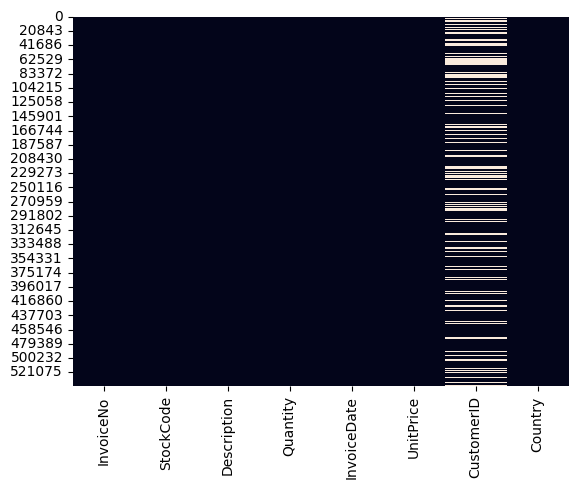

In [23]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [24]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

In [25]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

<Axes: xlabel='Country'>

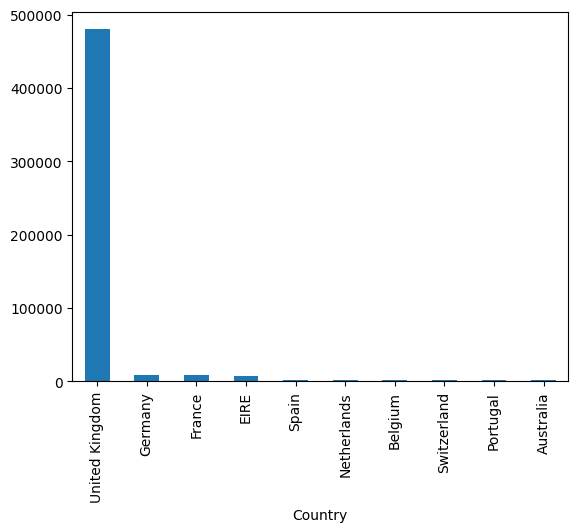

In [26]:
df['Country'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='Country'>

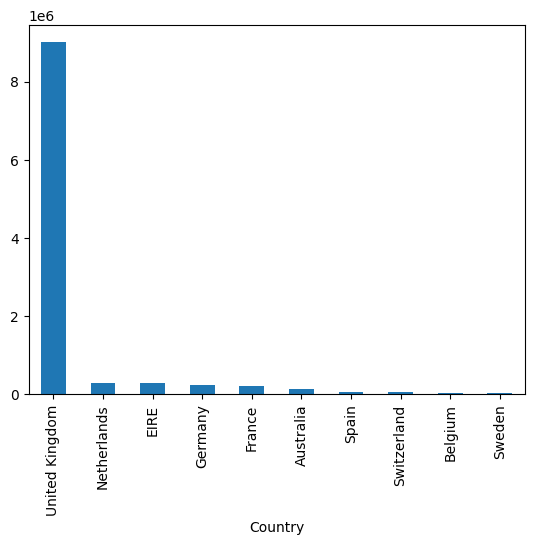

In [27]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

country_sales.plot(kind='bar')

<Axes: xlabel='Description'>

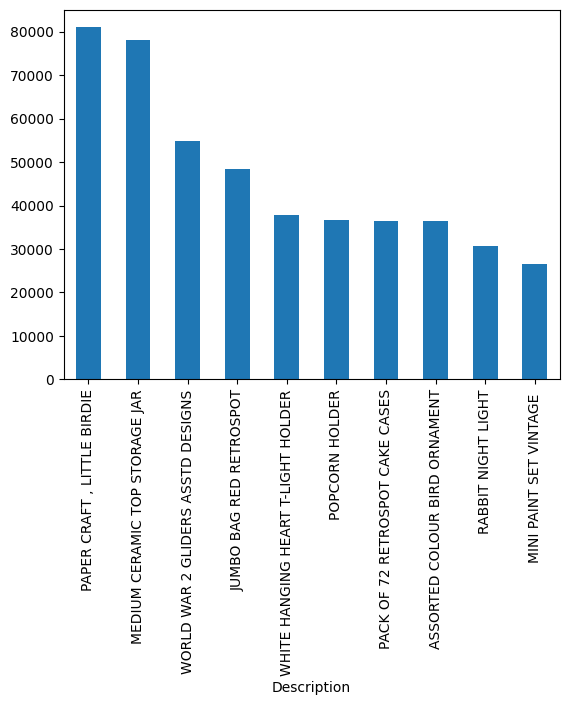

In [28]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar')

In [29]:
revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

In [30]:
df['Month'] = df['InvoiceDate'].dt.month

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

In [31]:
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum()

<Axes: xlabel='Hour', ylabel='count'>

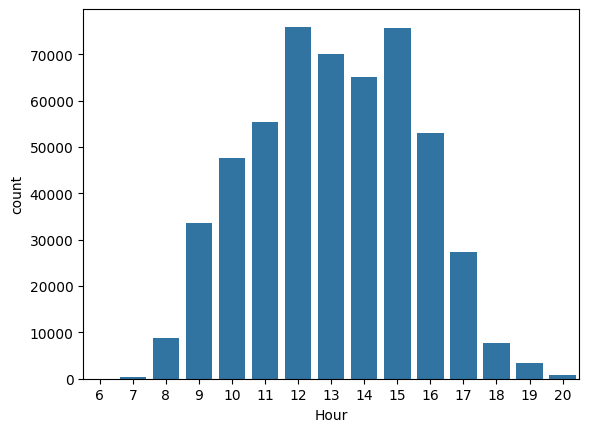

In [32]:
df['Hour'] = df['InvoiceDate'].dt.hour

sns.countplot(x='Hour', data=df)

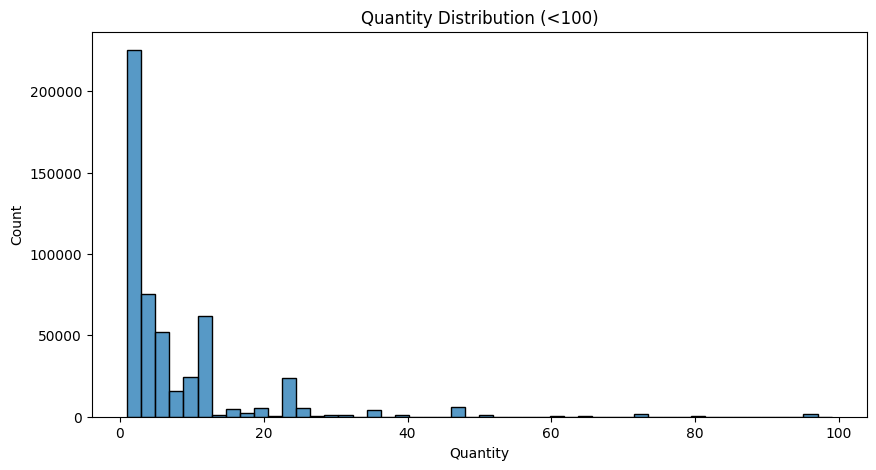

In [33]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['Quantity'] < 100]['Quantity'],
    bins=50
)

plt.title('Quantity Distribution (<100)')
plt.show()

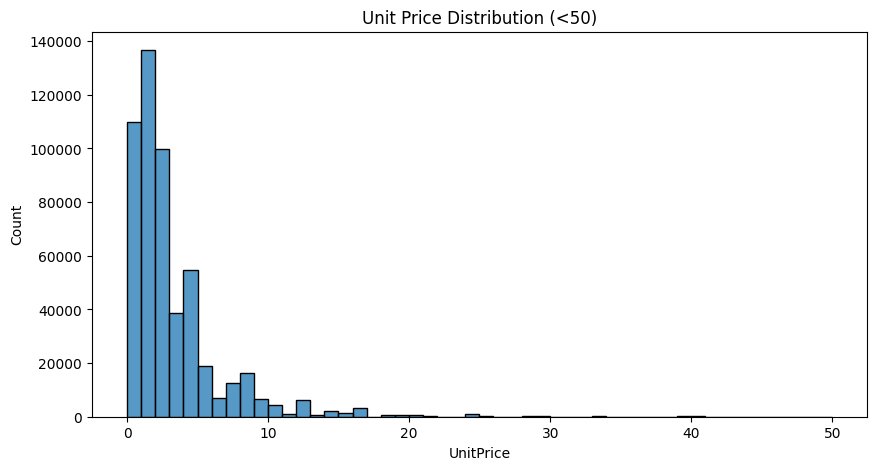

In [34]:
plt.figure(figsize=(10,5))

sns.histplot(
    df[df['UnitPrice'] < 50]['UnitPrice'],
    bins=50
)

plt.title('Unit Price Distribution (<50)')
plt.show()

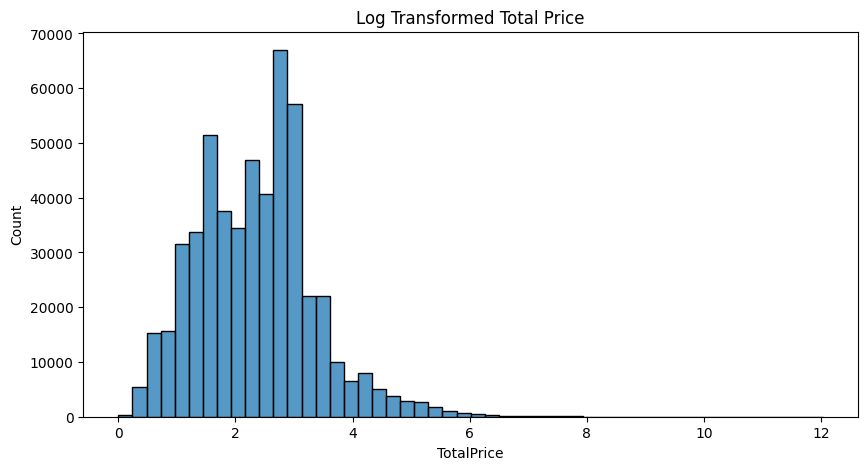

In [35]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df['TotalPrice']),
    bins=50
)

plt.title('Log Transformed Total Price')
plt.show()

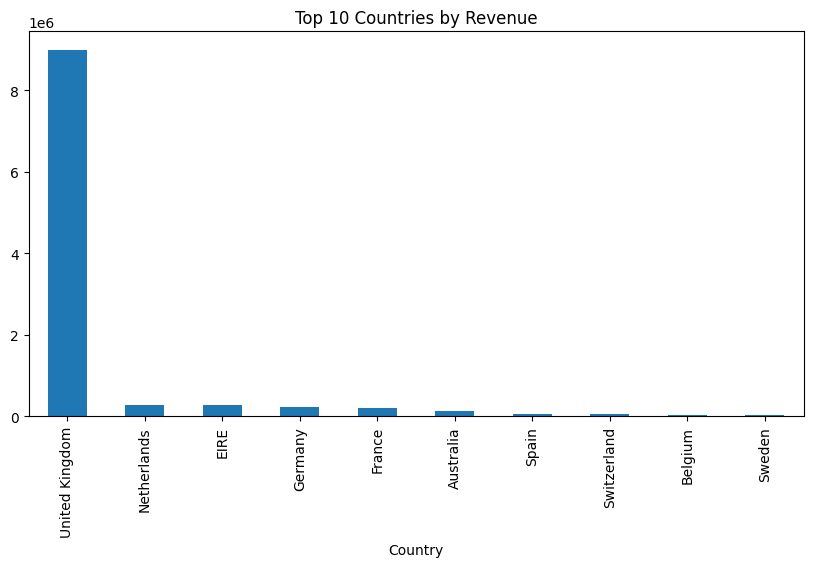

In [36]:
country_sales = (
    df.groupby('Country')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Countries by Revenue')
plt.show()

In [37]:
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

<Axes: xlabel='TotalPrice', ylabel='Count'>

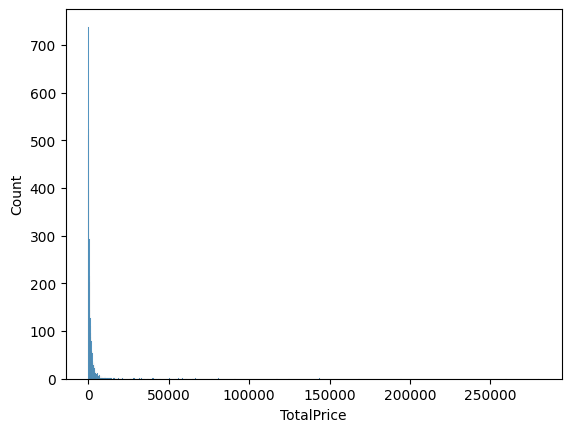

In [38]:
customer_spend = df.groupby('CustomerID')['TotalPrice'].sum()

sns.histplot(customer_spend)

<Axes: >

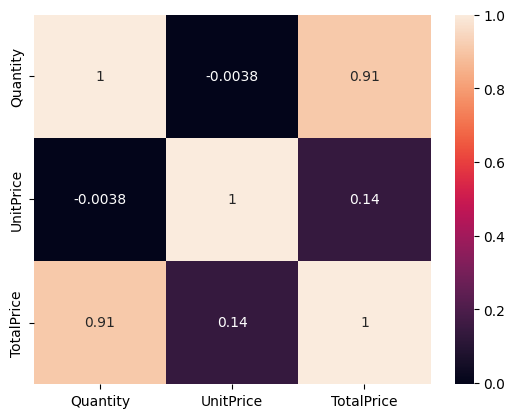

In [39]:
sns.heatmap(df[['Quantity','UnitPrice','TotalPrice']].corr(),
            annot=True)

<Axes: xlabel='Month'>

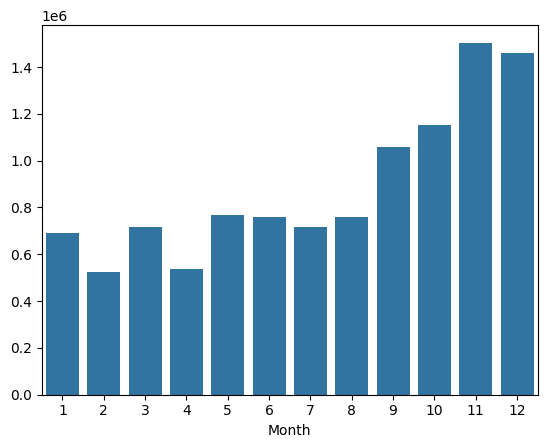

In [40]:
sns.barplot(x=monthly_sales.index,
            y=monthly_sales.values)